Überprüfung der Verbesserung bei Erhöhung der Label
1.Daten einlesen
2.Euklidische Distanz zu selbst gelabelten Koordinaten berechnen
3.Visualisierung

In [2]:
import pandas as pd

Old_Param_Optimized_100_labels = pd.read_csv(r'C:\Users\jrall\Desktop\Bachelorarbeit\Ergebnisse\Labels\Old Param 100 frames\First Run Opt Model 100 labels.analysis.csv')
Old_Param_Optimized_400_labels = pd.read_csv(r'C:\Users\jrall\Desktop\Bachelorarbeit\Ergebnisse\Labels\Old Param 400 Frames\Parameter Opti Model 400 Frames\Param Optimized 400 frames.000_video0030 25-01-23 18-49-44.analysis.csv')
Old_Param_Optimized_1000_labels = pd.read_csv(r'C:\Users\jrall\Desktop\Bachelorarbeit\Ergebnisse\Labels\Old Param Optimized 1000 frames\1000_frames.csv')

Selbst_gelabelte_Frames = pd.read_csv(r'C:\Users\jrall\Desktop\Bachelorarbeit\Ergebnisse\Generalisierungsvergleich\Gen Vergleich Selbst Gelabelt\Generalisierungsvergleich Template self labeled.000_video0030 25-01-23 18-49-44.analysis.csv')

New_Param_Optimized_100_labels = pd.read_csv(r'C:\Users\jrall\Desktop\Bachelorarbeit\Ergebnisse\Labels\New Param 100 frames\New Param 100 labels .analysis.csv')


In [3]:
New_Param_Optimized_100_labels

,track,frame_idx,instance.score,nose.x,nose.y,nose.score,neck.x,neck.y,neck.score,tail_base.x,tail_base.y,tail_base.score
0,NaN,0,0.944559,662.276733,619.401306,0.481179,NaN,NaN,0.0,645.867126,515.469421,0.731719
1,NaN,1,0.944281,660.259216,621.260681,0.499588,NaN,NaN,0.0,645.786804,515.588318,0.724966
2,NaN,2,0.943208,659.544434,621.815491,0.515599,NaN,NaN,0.0,645.773743,515.637573,0.716299
3,NaN,3,0.948817,657.282593,621.633972,0.495966,NaN,NaN,0.0,645.626038,515.504395,0.712009
4,NaN,4,0.961071,649.910706,620.949890,0.544845,NaN,NaN,0.0,645.500610,515.236450,0.704803
...,...,...,...,...,...,...,...,...,...,...,...,...
26652,NaN,27008,0.938446,881.732544,94.624161,0.203775,NaN,NaN,0.0,805.372253,210.141418,0.313741
26653,NaN,27009,0.941134,881.788452,94.660736,0.213579,NaN,NaN,0.0,805.391052,210.096924,0.316133
26654,NaN,27010,0.940660,881.782349,94.594582,0.221923,NaN,NaN,0.0,805.430237,210.075592,0.313047
26655,NaN,27011,0.941018,881.893799,94.556625,0.244351,NaN,NaN,0.0,805.489075,210.064697,0.307325


In [4]:
#Neue Datensätze erstellen die nur die Frames enthalten die auch selbst gelabelt wurden.
Old_PO_100_Vergleichsdatensatz = Old_Param_Optimized_100_labels[Old_Param_Optimized_100_labels['frame_idx'].isin(Selbst_gelabelte_Frames['frame_idx'])]
Old_PO_400_Vergleichsdatensatz = Old_Param_Optimized_400_labels[Old_Param_Optimized_400_labels['frame_idx'].isin(Selbst_gelabelte_Frames['frame_idx'])]
Old_PO_1000_Vergleichsdatensatz = Old_Param_Optimized_1000_labels[Old_Param_Optimized_1000_labels['frame_idx'].isin(Selbst_gelabelte_Frames['frame_idx'])]
New_PO_100_Vergleichsdatensatz = New_Param_Optimized_100_labels[New_Param_Optimized_100_labels['frame_idx'].isin(Selbst_gelabelte_Frames['frame_idx'])]

#Exportieren von Old_PO_100_Vergleichsdatensatz, Old_PO_1000_Vergleichsdatensatz und New_PO_100_Vergleichsdatensatz als csv Dateien
Old_PO_100_Vergleichsdatensatz.to_csv(r'C:\Users\jrall\Desktop\Bachelorarbeit\Ergebnisse\Labels\Statistik\Old_PO_100_Vergleichsdatensatz.csv', index=False)
Old_PO_1000_Vergleichsdatensatz.to_csv(r'C:\Users\jrall\Desktop\Bachelorarbeit\Ergebnisse\Labels\Statistik\Old_PO_1000_Vergleichsdatensatz.csv', index=False)
New_PO_100_Vergleichsdatensatz.to_csv(r'C:\Users\jrall\Desktop\Bachelorarbeit\Ergebnisse\Labels\Statistik\New_PO_100_Vergleichsdatensatz.csv', index=False)

In [5]:
#Euklidische Distanz zwischen den Modellen und selbst gelabelten Frames rausfinden für x und y Nose und in Distanz_zu_Selbst_gelabelten_Frames einfügen
import numpy as np

Distanz_zu_Selbst_gelabelten_Frames = []
for index, row in Selbst_gelabelte_Frames.iterrows():
    frame_idx = row['frame_idx']
    x_selbst_gelabelt = row['nose.x']
    y_selbst_gelabelt = row['nose.y']
    #Finde die Zeile in Old_PO_100_Vergleichsdatensatz mit dem gleichen frame_idx
    zeile_100 = Old_PO_100_Vergleichsdatensatz[Old_PO_100_Vergleichsdatensatz['frame_idx'] == frame_idx]
    zeile_400 = Old_PO_400_Vergleichsdatensatz[Old_PO_400_Vergleichsdatensatz['frame_idx'] == frame_idx]
    zeile_1000 = Old_PO_1000_Vergleichsdatensatz[Old_PO_1000_Vergleichsdatensatz['frame_idx'] == frame_idx]
    zeile_new_100 = New_PO_100_Vergleichsdatensatz[New_PO_100_Vergleichsdatensatz['frame_idx'] == frame_idx]
    if not zeile_100.empty and not zeile_400.empty and not zeile_1000.empty and not zeile_new_100.empty:
        x_100 = zeile_100['nose.x'].values[0]
        y_100 = zeile_100['nose.y'].values[0]
        x_400 = zeile_400['nose.x'].values[0]
        y_400 = zeile_400['nose.y'].values[0]
        x_1000 = zeile_1000['nose.x'].values[0]
        y_1000 = zeile_1000['nose.y'].values[0]
        x_new_100 = zeile_new_100['nose.x'].values[0]
        y_new_100 = zeile_new_100['nose.y'].values[0]
        
        distanz_100 = np.sqrt((x_selbst_gelabelt - x_100) ** 2 + (y_selbst_gelabelt - y_100) ** 2)
        distanz_400 = np.sqrt((x_selbst_gelabelt - x_400) ** 2 + (y_selbst_gelabelt - y_400) ** 2)
        distanz_1000 = np.sqrt((x_selbst_gelabelt - x_1000) ** 2 + (y_selbst_gelabelt - y_1000) ** 2)
        distanz_new_100 = np.sqrt((x_selbst_gelabelt - x_new_100) ** 2 + (y_selbst_gelabelt - y_new_100) ** 2)
        
        Distanz_zu_Selbst_gelabelten_Frames.append({'frame_idx': frame_idx, 'distanz_100': distanz_100, 'distanz_400': distanz_400, 'distanz_1000': distanz_1000, 'distanz_new_100': distanz_new_100})

Distanz_df = pd.DataFrame(Distanz_zu_Selbst_gelabelten_Frames)
print(Distanz_df)

#Exportieren von Distanz_df als csv Datei
Distanz_df.to_csv(r'C:\Users\jrall\Desktop\Bachelorarbeit\Ergebnisse\Labels\Statistik\Distanz_zu_Selbst_gelabelten_Frames.csv', index=False)

    frame_idx  distanz_100  distanz_400  distanz_1000  distanz_new_100
0       139.0    40.727474    16.707648      8.967714         4.655457
1       667.0    36.453777    23.391156      9.249340              NaN
2      1211.0    25.310094    17.056521     18.048986         5.022768
3      1536.0    25.564680     8.650586     12.489833         4.371824
4      1879.0    23.848119    17.183790     10.095839         9.540562
..        ...          ...          ...           ...              ...
92    26209.0    39.708871    41.012301     28.425980              NaN
93    26538.0    52.122628    35.668594     20.595900              NaN
94    26828.0          NaN          NaN           NaN              NaN
95    26867.0    26.844652    13.532515     20.755726         3.050924
96    27008.0    24.855455    18.088812     43.751126        39.350127

[97 rows x 5 columns]


In [6]:
#Euklidische Distanz zwischen den Modellen und selbst gelabelten Frames rausfinden für x und y Neck und in Distanz_zu_Selbst_gelabelten_Frames_Nacken einfügen
import numpy as np

Distanz_zu_Selbst_gelabelten_Frames_Nacken = []
for index, row in Selbst_gelabelte_Frames.iterrows():
    frame_idx = row['frame_idx']
    x_selbst_gelabelt = row['neck.x']
    y_selbst_gelabelt = row['neck.y']
    #Finde die Zeile in Old_PO_100_Vergleichsdatensatz mit dem gleichen frame_idx
    zeile_100 = Old_PO_100_Vergleichsdatensatz[Old_PO_100_Vergleichsdatensatz['frame_idx'] == frame_idx]
    zeile_400 = Old_PO_400_Vergleichsdatensatz[Old_PO_400_Vergleichsdatensatz['frame_idx'] == frame_idx]
    zeile_1000 = Old_PO_1000_Vergleichsdatensatz[Old_PO_1000_Vergleichsdatensatz['frame_idx'] == frame_idx]
    zeile_new_100 = New_PO_100_Vergleichsdatensatz[New_PO_100_Vergleichsdatensatz['frame_idx'] == frame_idx]
    if not zeile_100.empty and not zeile_400.empty and not zeile_1000.empty and not zeile_new_100.empty:
        x_100 = zeile_100['neck.x'].values[0]
        y_100 = zeile_100['neck.y'].values[0]
        x_400 = zeile_400['neck.x'].values[0]
        y_400 = zeile_400['neck.y'].values[0]
        x_1000 = zeile_1000['neck.x'].values[0]
        y_1000 = zeile_1000['neck.y'].values[0]
        x_new_100 = zeile_new_100['neck.x'].values[0]
        y_new_100 = zeile_new_100['neck.y'].values[0]
        
        distanz_100 = np.sqrt((x_selbst_gelabelt - x_100) ** 2 + (y_selbst_gelabelt - y_100) ** 2)
        distanz_400 = np.sqrt((x_selbst_gelabelt - x_400) ** 2 + (y_selbst_gelabelt - y_400) ** 2)
        distanz_1000 = np.sqrt((x_selbst_gelabelt - x_1000) ** 2 + (y_selbst_gelabelt - y_1000) ** 2)
        distanz_new_100 = np.sqrt((x_selbst_gelabelt - x_new_100) ** 2 + (y_selbst_gelabelt - y_new_100) ** 2)
        
        Distanz_zu_Selbst_gelabelten_Frames_Nacken.append({'frame_idx': frame_idx, 'distanz_100': distanz_100, 'distanz_400': distanz_400, 'distanz_1000': distanz_1000, 'distanz_new_100': distanz_new_100})

Distanz_df_Nacken = pd.DataFrame(Distanz_zu_Selbst_gelabelten_Frames_Nacken)
print(Distanz_df_Nacken)

#Exportieren von Distanz_df als csv Datei
Distanz_df_Nacken.to_csv(r'C:\Users\jrall\Desktop\Bachelorarbeit\Ergebnisse\Labels\Statistik\Distanz_zu_Selbst_gelabelten_Frames_Nacken.csv', index=False)

    frame_idx  distanz_100  distanz_400  distanz_1000  distanz_new_100
0       139.0    23.096660    22.943440      6.438952        15.906805
1       667.0    18.741456    11.788535     12.432044        26.421676
2      1211.0    22.585318    22.328222     15.160480              NaN
3      1536.0    12.416340    14.833346     13.088029        66.727056
4      1879.0    10.143201    15.826718     15.275946        22.035494
..        ...          ...          ...           ...              ...
92    26209.0    24.917926    24.658434     24.989530        13.865633
93    26538.0    12.113761    13.121636     12.617810              NaN
94    26828.0    17.166048    36.509805     34.647869              NaN
95    26867.0     8.750326    15.999734     14.040703              NaN
96    27008.0    51.981581    27.761753     51.160405              NaN

[97 rows x 5 columns]


In [7]:
#Euklidische Distanz zwischen den Modellen und selbst gelabelten Frames rausfinden für x und y tail_base und in Distanz_zu_Selbst_gelabelten_Frames_tail_base einfügen
import numpy as np

Distanz_zu_Selbst_gelabelten_Frames_Tail_base = []
for index, row in Selbst_gelabelte_Frames.iterrows():
    frame_idx = row['frame_idx']
    x_selbst_gelabelt = row['tail_base.x']
    y_selbst_gelabelt = row['tail_base.y']
    #Finde die Zeile in Old_PO_100_Vergleichsdatensatz mit dem gleichen frame_idx
    zeile_100 = Old_PO_100_Vergleichsdatensatz[Old_PO_100_Vergleichsdatensatz['frame_idx'] == frame_idx]
    zeile_400 = Old_PO_400_Vergleichsdatensatz[Old_PO_400_Vergleichsdatensatz['frame_idx'] == frame_idx]
    zeile_1000 = Old_PO_1000_Vergleichsdatensatz[Old_PO_1000_Vergleichsdatensatz['frame_idx'] == frame_idx]
    zeile_new_100 = New_PO_100_Vergleichsdatensatz[New_PO_100_Vergleichsdatensatz['frame_idx'] == frame_idx]
    if not zeile_100.empty and not zeile_400.empty and not zeile_1000.empty and not zeile_new_100.empty:
        x_100 = zeile_100['tail_base.x'].values[0]
        y_100 = zeile_100['tail_base.y'].values[0]
        x_400 = zeile_400['tail_base.x'].values[0]
        y_400 = zeile_400['tail_base.y'].values[0]
        x_1000 = zeile_1000['tail_base.x'].values[0]
        y_1000 = zeile_1000['tail_base.y'].values[0]
        x_new_100 = zeile_new_100['tail_base.x'].values[0]
        y_new_100 = zeile_new_100['tail_base.y'].values[0]
        
        distanz_100 = np.sqrt((x_selbst_gelabelt - x_100) ** 2 + (y_selbst_gelabelt - y_100) ** 2)
        distanz_400 = np.sqrt((x_selbst_gelabelt - x_400) ** 2 + (y_selbst_gelabelt - y_400) ** 2)
        distanz_1000 = np.sqrt((x_selbst_gelabelt - x_1000) ** 2 + (y_selbst_gelabelt - y_1000) ** 2)
        distanz_new_100 = np.sqrt((x_selbst_gelabelt - x_new_100) ** 2 + (y_selbst_gelabelt - y_new_100) ** 2)
        
        Distanz_zu_Selbst_gelabelten_Frames_Tail_base.append({'frame_idx': frame_idx, 'distanz_100': distanz_100, 'distanz_400': distanz_400, 'distanz_1000': distanz_1000, 'distanz_new_100': distanz_new_100})

Distanz_df_Tail_base = pd.DataFrame(Distanz_zu_Selbst_gelabelten_Frames_Tail_base)
print(Distanz_df_Tail_base)

#Exportieren von Distanz_df als csv Datei
Distanz_df_Tail_base.to_csv(r'C:\Users\jrall\Desktop\Bachelorarbeit\Ergebnisse\Labels\Statistik\Distanz_zu_Selbst_gelabelten_Frames_Tail_base.csv', index=False)

    frame_idx  distanz_100  distanz_400  distanz_1000  distanz_new_100
0       139.0    33.309685    33.695725     50.793180         3.816774
1       667.0    16.279895    31.966562     30.983459         2.443887
2      1211.0    14.590730    15.196640     26.641776         2.364901
3      1536.0    33.489003    20.761115     19.761684              NaN
4      1879.0    55.602254    55.908242     56.495835         9.868434
..        ...          ...          ...           ...              ...
92    26209.0    24.599932    35.556390     24.820659         1.814892
93    26538.0    21.020106    23.534588     14.557747         0.396231
94    26828.0     8.597644    28.925926     38.105666         1.173484
95    26867.0    11.750951    17.896042     17.248316         2.837132
96    27008.0   176.991664    56.057147     70.016891        11.986956

[97 rows x 5 columns]


In [8]:
Distanz_df

,frame_idx,distanz_100,distanz_400,distanz_1000,distanz_new_100
0,139.0,40.727474,16.707648,8.967714,4.655457
1,667.0,36.453777,23.391156,9.249340,NaN
2,1211.0,25.310094,17.056521,18.048986,5.022768
3,1536.0,25.564680,8.650586,12.489833,4.371824
4,1879.0,23.848119,17.183790,10.095839,9.540562
...,...,...,...,...,...
92,26209.0,39.708871,41.012301,28.425980,NaN
93,26538.0,52.122628,35.668594,20.595900,NaN
94,26828.0,NaN,NaN,NaN,NaN
95,26867.0,26.844652,13.532515,20.755726,3.050924


In [9]:
Distanz_df_Tail_base

,frame_idx,distanz_100,distanz_400,distanz_1000,distanz_new_100
0,139.0,33.309685,33.695725,50.793180,3.816774
1,667.0,16.279895,31.966562,30.983459,2.443887
2,1211.0,14.590730,15.196640,26.641776,2.364901
3,1536.0,33.489003,20.761115,19.761684,NaN
4,1879.0,55.602254,55.908242,56.495835,9.868434
...,...,...,...,...,...
92,26209.0,24.599932,35.556390,24.820659,1.814892
93,26538.0,21.020106,23.534588,14.557747,0.396231
94,26828.0,8.597644,28.925926,38.105666,1.173484
95,26867.0,11.750951,17.896042,17.248316,2.837132


In [10]:
Distanz_df_Nacken

,frame_idx,distanz_100,distanz_400,distanz_1000,distanz_new_100
0,139.0,23.096660,22.943440,6.438952,15.906805
1,667.0,18.741456,11.788535,12.432044,26.421676
2,1211.0,22.585318,22.328222,15.160480,NaN
3,1536.0,12.416340,14.833346,13.088029,66.727056
4,1879.0,10.143201,15.826718,15.275946,22.035494
...,...,...,...,...,...
92,26209.0,24.917926,24.658434,24.989530,13.865633
93,26538.0,12.113761,13.121636,12.617810,NaN
94,26828.0,17.166048,36.509805,34.647869,NaN
95,26867.0,8.750326,15.999734,14.040703,NaN


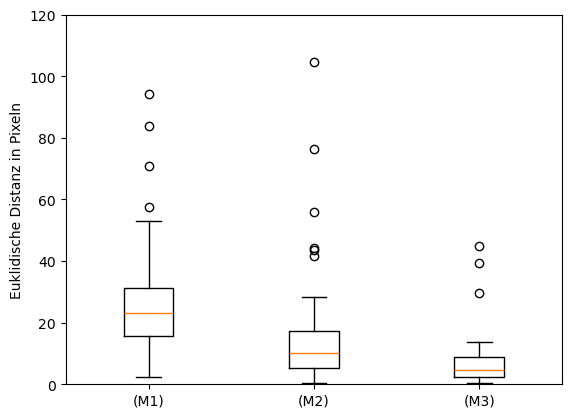

In [11]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

data = [
    Distanz_df['distanz_100'].dropna(),
    Distanz_df['distanz_1000'].dropna(),
    Distanz_df['distanz_new_100'].dropna()
]

ax.boxplot(
    data,
    tick_labels=['(M1)','(M2)','(M3)']
)

ax.set_ylabel("Euklidische Distanz in Pixeln")
ax.set_title("")
plt.ylim(0, 120)
plt.show()




In [12]:
import numpy as np
mean_distanz_100 = Distanz_df['distanz_100'].mean()
sem_distanz_100 = Distanz_df['distanz_100'].sem()
median_distanz_100 = Distanz_df['distanz_100'].median()
print(f"Old Param 100 Labels: Mean Distanz = {mean_distanz_100}, SEM = {sem_distanz_100}, Median = {median_distanz_100}")
mean_distanz_1000 = Distanz_df['distanz_1000'].mean()
sem_distanz_1000 = Distanz_df['distanz_1000'].sem()
median_distanz_1000 = Distanz_df['distanz_1000'].median()
print(f"Old Param 1000 Labels: Mean Distanz = {mean_distanz_1000}, SEM = {sem_distanz_1000}, Median = {median_distanz_1000}")
mean_distanz_new_100 = Distanz_df['distanz_new_100'].mean()
sem_distanz_new_100 = Distanz_df['distanz_new_100'].sem()
median_distanz_new_100 = Distanz_df['distanz_new_100'].median()
print(f"New Param 100 Labels: Mean Distanz = {mean_distanz_new_100}, SEM = {sem_distanz_new_100}, Median = {median_distanz_new_100}")

Old Param 100 Labels: Mean Distanz = 26.030874530751287, SEM = 1.6061198555558611, Median = 23.234440289461368
Old Param 1000 Labels: Mean Distanz = 13.929920777264302, SEM = 1.5552782325807057, Median = 10.095839008007141
New Param 100 Labels: Mean Distanz = 7.786564695508657, SEM = 1.717838029974949, Median = 4.655457130334419


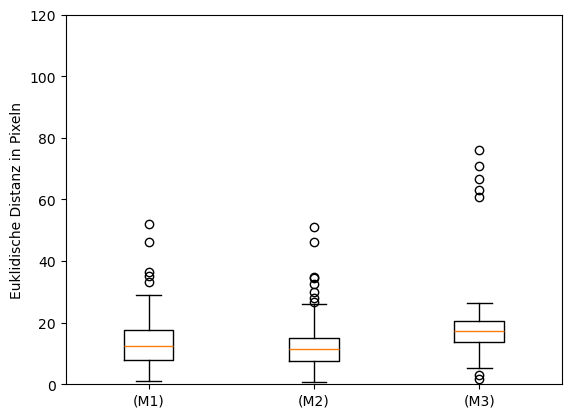

Old Param 100 Labels: Mean Distanz = 14.052289034271778, SEM = 0.9155902352349624, Median = 12.416340149198474
Old Param 1000 Labels: Mean Distanz = 12.905804818179195, SEM = 0.8765812494550453, Median = 11.412387724743699
New Param 100 Labels: Mean Distanz = 21.239690570441383, SEM = 2.3722270604517703, Median = 17.18473390714718


In [13]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

data = [
    Distanz_df_Nacken['distanz_100'].dropna(),
    Distanz_df_Nacken['distanz_1000'].dropna(),
    Distanz_df_Nacken['distanz_new_100'].dropna()
]

ax.boxplot(
    data,
    tick_labels=['(M1)','(M2)','(M3)']
)

ax.set_ylabel("Euklidische Distanz in Pixeln")
ax.set_title("")
plt.ylim(0, 120)
plt.show()

#SEM und Mittelwert für Neck
mean_distanz_100_nacken = Distanz_df_Nacken['distanz_100'].mean()
sem_distanz_100_nacken = Distanz_df_Nacken['distanz_100'].sem()
median_distanz_100_nacken = Distanz_df_Nacken['distanz_100'].median()
print(f"Old Param 100 Labels: Mean Distanz = {mean_distanz_100_nacken}, SEM = {sem_distanz_100_nacken}, Median = {median_distanz_100_nacken}")
mean_distanz_1000_nacken = Distanz_df_Nacken['distanz_1000'].mean()
sem_distanz_1000_nacken = Distanz_df_Nacken['distanz_1000'].sem()
median_distanz_1000_nacken = Distanz_df_Nacken['distanz_1000'].median()
print(f"Old Param 1000 Labels: Mean Distanz = {mean_distanz_1000_nacken}, SEM = {sem_distanz_1000_nacken}, Median = {median_distanz_1000_nacken}")
mean_distanz_new_100_nacken = Distanz_df_Nacken['distanz_new_100'].mean()
sem_distanz_new_100_nacken = Distanz_df_Nacken['distanz_new_100'].sem()
median_distanz_new_100_nacken = Distanz_df_Nacken['distanz_new_100'].median()
print(f"New Param 100 Labels: Mean Distanz = {mean_distanz_new_100_nacken}, SEM = {sem_distanz_new_100_nacken}, Median = {median_distanz_new_100_nacken}")




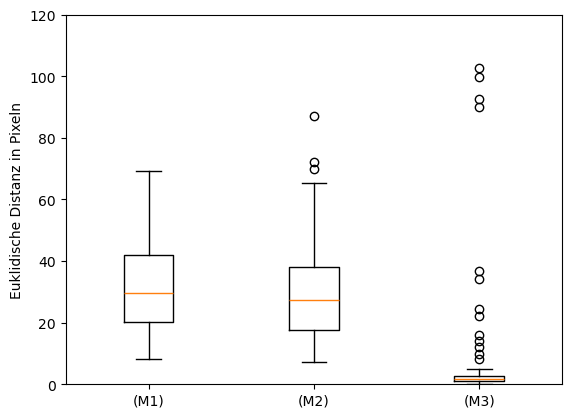

Old Param 100 Labels: Mean Distanz = 33.33754766686548, SEM = 2.5056481655101677, Median = 29.610270078389647
Old Param 1000 Labels: Mean Distanz = 30.550990271823125, SEM = 1.9126525460931616, Median = 27.482470776139976
New Param 100 Labels: Mean Distanz = 7.52001104799198, SEM = 2.0926726047934214, Median = 1.591058182075814


In [14]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

data = [
    Distanz_df_Tail_base['distanz_100'].dropna(),
    Distanz_df_Tail_base['distanz_1000'].dropna(),
    Distanz_df_Tail_base['distanz_new_100'].dropna()
]

ax.boxplot(
    data,
    tick_labels=['(M1)','(M2)','(M3)']
)

ax.set_ylabel("Euklidische Distanz in Pixeln")
ax.set_title("")
plt.ylim(0, 120)
plt.show()

#SEM und Mittelwert für Tail_base
mean_distanz_100_tail_base = Distanz_df_Tail_base['distanz_100'].mean()
sem_distanz_100_tail_base = Distanz_df_Tail_base['distanz_100'].sem()
median_distanz_100_tail_base = Distanz_df_Tail_base['distanz_100'].median()
print(f"Old Param 100 Labels: Mean Distanz = {mean_distanz_100_tail_base}, SEM = {sem_distanz_100_tail_base}, Median = {median_distanz_100_tail_base}")
mean_distanz_1000_tail_base = Distanz_df_Tail_base['distanz_1000'].mean()
sem_distanz_1000_tail_base = Distanz_df_Tail_base['distanz_1000'].sem()
median_distanz_1000_tail_base = Distanz_df_Tail_base['distanz_1000'].median()
print(f"Old Param 1000 Labels: Mean Distanz = {mean_distanz_1000_tail_base}, SEM = {sem_distanz_1000_tail_base}, Median = {median_distanz_1000_tail_base}")
mean_distanz_new_100_tail_base = Distanz_df_Tail_base['distanz_new_100'].mean()
sem_distanz_new_100_tail_base = Distanz_df_Tail_base['distanz_new_100'].sem()
median_distanz_new_100_tail_base = Distanz_df_Tail_base['distanz_new_100'].median()
print(f"New Param 100 Labels: Mean Distanz = {mean_distanz_new_100_tail_base}, SEM = {sem_distanz_new_100_tail_base}, Median = {median_distanz_new_100_tail_base}")

In [17]:
data_Nose = Distanz_df[['distanz_100', 'distanz_1000', 'distanz_new_100']]
data_Nose

,distanz_100,distanz_1000,distanz_new_100
0,40.727474,8.967714,4.655457
1,36.453777,9.249340,NaN
2,25.310094,18.048986,5.022768
3,25.564680,12.489833,4.371824
4,23.848119,10.095839,9.540562
...,...,...,...
92,39.708871,28.425980,NaN
93,52.122628,20.595900,NaN
94,NaN,NaN,NaN
95,26.844652,20.755726,3.050924


In [18]:
data_Nacken = Distanz_df_Nacken[['distanz_100', 'distanz_1000', 'distanz_new_100']]
data_Nacken

,distanz_100,distanz_1000,distanz_new_100
0,23.096660,6.438952,15.906805
1,18.741456,12.432044,26.421676
2,22.585318,15.160480,NaN
3,12.416340,13.088029,66.727056
4,10.143201,15.275946,22.035494
...,...,...,...
92,24.917926,24.989530,13.865633
93,12.113761,12.617810,NaN
94,17.166048,34.647869,NaN
95,8.750326,14.040703,NaN


In [19]:
data_Schwanzbasis = Distanz_df_Tail_base[['distanz_100', 'distanz_1000', 'distanz_new_100']]
data_Schwanzbasis

,distanz_100,distanz_1000,distanz_new_100
0,33.309685,50.793180,3.816774
1,16.279895,30.983459,2.443887
2,14.590730,26.641776,2.364901
3,33.489003,19.761684,NaN
4,55.602254,56.495835,9.868434
...,...,...,...
92,24.599932,24.820659,1.814892
93,21.020106,14.557747,0.396231
94,8.597644,38.105666,1.173484
95,11.750951,17.248316,2.837132
